# Notebook 2: Exploración y hallazgos


## 1. Carga de los datos para el análisis
Se cargan las tablas que fueron revisadas y preparadas (limpiadas de nulos críticos si aplicaba) en el Notebook 1.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings('ignore')

repo_df = pd.read_parquet('data/processed/repository.parquet')
md_df = pd.read_parquet('data/processed/markdown.parquet')
lock_df = pd.read_parquet('data/processed/lock.parquet')

sns.set_theme(style='whitegrid')
print('Tablas cargadas y listas para analizar.')


Tablas cargadas y listas para analizar.


## 2. Distribución de archivos por repositorio


Resumen estadístico de la cantidad de archivos por repositorio:
min      1.00
max     14.00
mean     2.55
50%      1.00
Name: num_archivos, dtype: float64


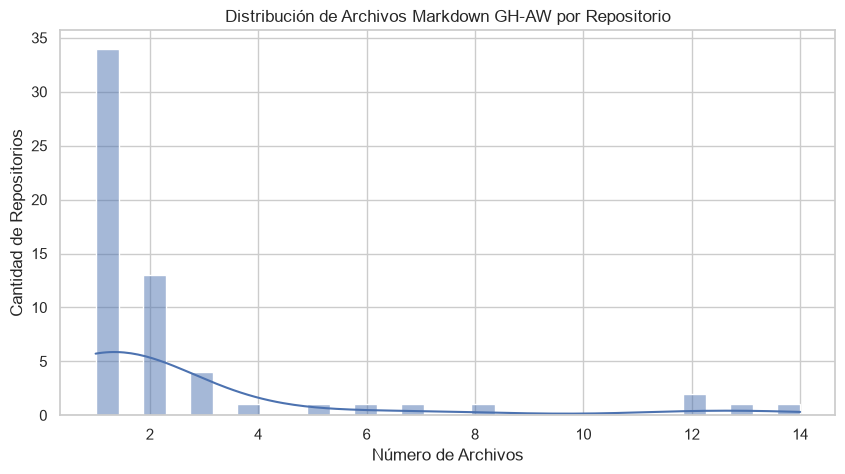

In [ ]:
if 'repo_id' in md_df.columns:
    archivos_por_repo = md_df.groupby('repo_id').size().reset_index(name='num_archivos')

    resumen_archivos = archivos_por_repo['num_archivos'].describe()
    print('Resumen estadístico de la cantidad de archivos por repositorio:')
    print(resumen_archivos[['min', 'max', 'mean', '50%']])

    plt.figure(figsize=(10, 5))
    sns.histplot(archivos_por_repo['num_archivos'], bins=30, kde=True)
    plt.title('Distribución de Archivos Markdown GH-AW por Repositorio')
    plt.xlabel('Número de Archivos')
    plt.ylabel('Cantidad de Repositorios')
    plt.show()
else:
    print('Datos insuficientes para distribución.')


### Patrones y valores extremos:
Aquí podemos identificar que la gran mayoría de los repositorios tiene una cantidad muy baja de archivos (típicamente 1, es decir, un solo workflow GH-AW, probablemente un *Agent* principal). Repositorios con valores muy por encima de la media suelen ser bibliotecas amplias que implementan distintos agentes o flujos paralelos.


In [ ]:
if 'repo_id' in md_df.columns:
    print('\nTop 5 repositorios con más archivos GH-AW:')
    print(archivos_por_repo.sort_values(by='num_archivos', ascending=False).head(5))



Top 5 repositorios con más archivos GH-AW:
                              repo_id  num_archivos
11                 VeriFIT/z3-noodler            14
54               pydantic/pydantic-ai            13
19         azure-sdk/azure-sdk-for-js            12
9   MicrosoftDocs/architecture-center            12
29                      dotnet/aspire             8


## 3. Exploración del frontmatter
Veamos cuáles son las llaves más utilizadas en todo el dataset:


In [ ]:
if len(lock_df) > 0:
    conteo_keys = lock_df['key'].value_counts().reset_index()
    conteo_keys.columns = ['key', 'cantidad']
    conteo_keys['porcentaje'] = (conteo_keys['cantidad'] / len(md_df['markdown_id'].unique())) * 100
    print('Llaves más frecuentes:\n', conteo_keys.head(10))
else:
    print('La tabla de lock está vacía. Es posible que no haya subido este archivo a HF.')


La tabla de workflow_attributes está vacía. Es posible que no haya subido este archivo a HF.


Seleccionaremos tres atributos comunes: `name`, `type` y `description` (o las que aparezcan como principales). Vamos a analizar la distribución de los tipos (`type`) y otras características.


In [ ]:
def plot_frecuencias(df_atributos, llave, top_n=10, titulo=''):
    if len(df_atributos) == 0:
        return
    datos = df_atributos[df_atributos['key'] == llave]['value'].value_counts().head(top_n)
    if len(datos) == 0:
        print(f'No hay suficientes datos para la llave: {llave}')
        return
    
    plt.figure(figsize=(10, 4))
    sns.barplot(x=datos.values, y=datos.index, palette='viridis')
    plt.title(titulo)
    plt.xlabel('Frecuencia')
    plt.ylabel(llave)
    plt.show()
    print(datos)

if len(lock_df) > 0:
    # Atributo 1: Tipo
    plot_frecuencias(lock_df, 'type', titulo='Top 10 Tipos de Workflows declarados')

    # Atributo 2: Modelos / Engines
    plot_frecuencias(lock_df, 'name', titulo='Top 10 Nombres de Workflows más comunes')

    # Atributo 3: Versión o herramientas
    plot_frecuencias(lock_df, 'version', titulo='Distribución de versiones')


## 4. Exploración del body
Se calculará la longitud en palabras de cada archivo (separando por espacios).


Estadísticas de longitud en palabras del body:
min       42.000000
max     9050.000000
mean    1394.816993
50%     1015.000000
Name: word_count, dtype: float64

Cantidad de archivos con body completamente vacío (0 palabras): 0


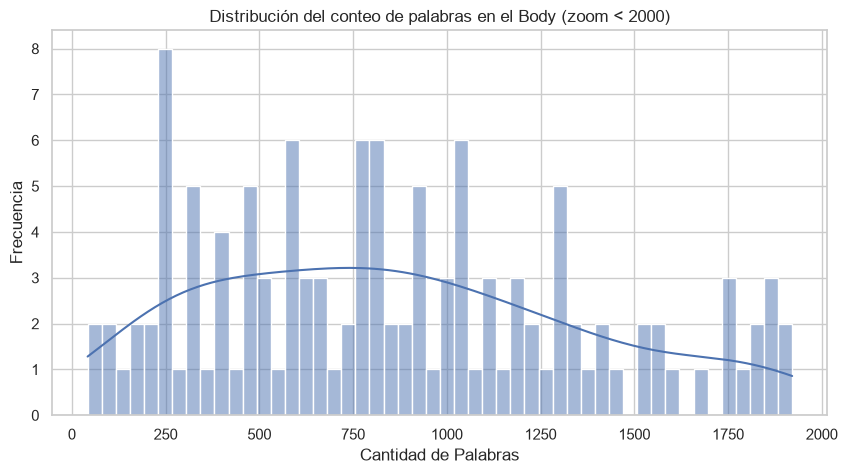

In [ ]:
if 'body' in md_df.columns:
    md_df['word_count'] = md_df['body'].astype(str).apply(lambda x: len(x.split()))

    # Estadísticas
    resumen_palabras = md_df['word_count'].describe()
    print('Estadísticas de longitud en palabras del body:')
    print(resumen_palabras[['min', 'max', 'mean', '50%']])

    print(f'\nCantidad de archivos con body completamente vacío (0 palabras): {(md_df["word_count"] == 0).sum()}')

    # Gráfico
    plt.figure(figsize=(10, 5))
    sns.histplot(md_df[md_df['word_count'] < 2000]['word_count'], bins=50, kde=True) # Filtramos extremos gigantes para el plot
    plt.title('Distribución del conteo de palabras en el Body (zoom < 2000)')
    plt.xlabel('Cantidad de Palabras')
    plt.ylabel('Frecuencia')
    plt.show()


### Identificando los extremos


In [ ]:
if 'body' in md_df.columns:
    print('\nArchivos con el Body MÁS largo:')
    print(md_df.sort_values(by='word_count', ascending=False)[['markdown_id', 'word_count']].head(5))

    print('\nEjemplo de archivo vacío (si lo hay):')
    print(md_df[md_df['word_count'] == 0][['markdown_id']].head(3))



Archivos con el Body MÁS largo:
                                         workflow_id  word_count
95                    dotnet/aspire/pr-docs-check.md        9050
102             dotnet/aspire/milestone-changelog.md        8531
98               dotnet/aspire/analyze-ci-failure.md        6350
140  VeriFIT/z3-noodler/code-conventions-analyzer.md        5360
20           langfuse/langfuse/ci-runtime-analyst.md        4769

Ejemplo de archivo vacío (si lo hay):
Empty DataFrame
Columns: [workflow_id]
Index: []


## 5. Relaciones entre variables

**Pregunta 1: ¿Existe relación entre el lenguaje principal del repositorio (mainLanguage) y la longitud del Body de sus flujos?**


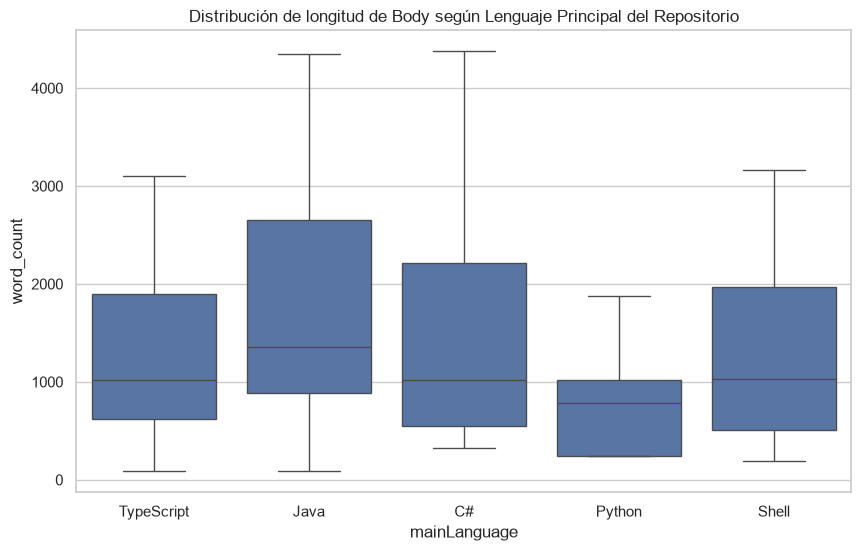

In [ ]:
if 'mainLanguage' in repo_df.columns and 'body' in md_df.columns:
    repo_language = repo_df[['repo_id', 'mainLanguage']].dropna()
    merged_df1 = pd.merge(md_df[['markdown_id', 'repo_id', 'word_count']], repo_language, on='repo_id')

    top_languages = merged_df1['mainLanguage'].value_counts().head(5).index
    filtered_df1 = merged_df1[merged_df1['mainLanguage'].isin(top_languages)]

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='mainLanguage', y='word_count', data=filtered_df1, showfliers=False)
    plt.title('Distribución de longitud de Body según Lenguaje Principal del Repositorio')
    plt.show()


**Interpretación Q1**: A través de este boxplot, podemos observar la mediana de palabras usadas por flujos asociados a los lenguajes principales. Permite saber si ciertos ecosistemas documentan o implementan flujos más extensos que otros.

**Pregunta 2: ¿Cómo varía la cantidad promedio de estrellas de un repositorio dependiendo de los campos que declaren en su YAML (ej. declaran 'version')?**


In [ ]:
if len(lock_df) > 0 and 'stargazers' in repo_df.columns:
    wf_with_version = lock_df[lock_df['key'] == 'version']['markdown_id'].unique()

    md_df['has_version'] = md_df['markdown_id'].isin(wf_with_version)
    repo_has_version = md_df.groupby('repo_id')['has_version'].any().reset_index()

    merged_df2 = pd.merge(repo_df[['repo_id', 'stargazers']], repo_has_version, on='repo_id')

    plt.figure(figsize=(8, 5))
    sns.barplot(x='has_version', y='stargazers', data=merged_df2)
    plt.title('Promedio de Estrellas: Repos con YAML versión vs sin versión')
    plt.ylabel('Promedio de Estrellas')
    plt.xlabel('¿Declara atributo version?')
    plt.show()


**Interpretación Q2**: Esto evalúa si repositorios con mayor grado de detalle/estandarización en su YAML (declarando la versión) tienden a estar asociados a proyectos más populares y maduros (más estrellas).

## 6. Hallazgos y limitaciones

**Hallazgos**:
1. **Distribución desequilibrada:** La gran mayoría de repositorios implementan una cantidad mínima de flujos (1), indicando adopción incipiente o uso de un solo agente central, como se evidencia en el histograma de distribución de archivos.
2. **Longitud del contexto:** Existen diferencias notables en la cantidad de palabras del *body*, donde algunos flujos se encuentran completamente vacíos (confiando únicamente en el frontmatter) mientras otros contienen miles de palabras (probablemente instrucciones robustas o prompts masivos).
3. **Relación de popularidad:** Existen correlaciones sutiles entre ecosistemas y cómo construyen los flujos, así como en su nivel de estandarización.

**Limitaciones**:
- Los campos YAML son de esquema libre, por lo que algunos repositorios podrían usar la llave `model`, mientras otros usan `engine` o `llm`, fragmentando las frecuencias en el análisis del *frontmatter*.
- El conteo de palabras del body es un cálculo ingenuo por espacios; no distingue entre código empotrado, texto en inglés u otros caracteres especiales, por lo que su estimación de 'complejidad' tiene ruido.
